<a href="https://colab.research.google.com/github/jsruis/gdp-dashboard/blob/main/Te_damos_la_bienvenida_a_Colaboratory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_11760/569067927.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_excel('Serie pruebas.xlsx', parse_dates=['Toma'], index_col='Toma')


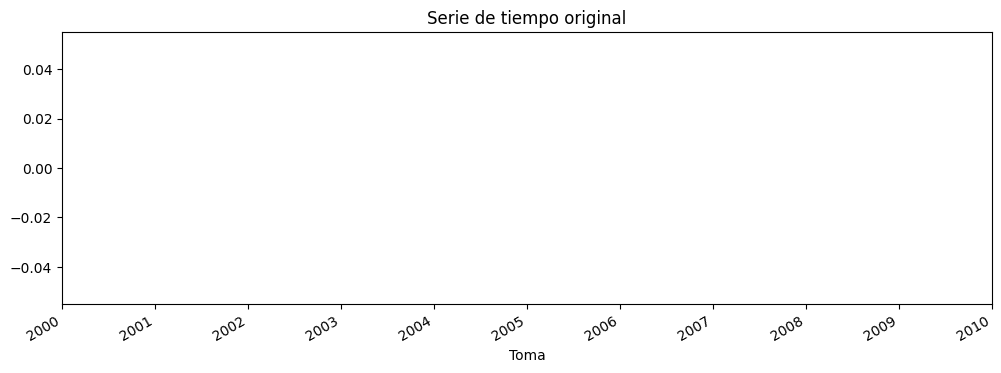

ValueError: zero-size array to reduction operation maximum which has no identity

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
!pip install pmdarima

# ─── 1. CARGAR Y VISUALIZAR ───────────────────────────────────────────────────
df = pd.read_excel('Serie pruebas.xlsx', parse_dates=['Toma'], index_col='Toma')
df = df.asfreq('MS')  # frecuencia mensual

# Handle potential NaNs introduced by asfreq or existing in the data
df['ventas'] = df['ventas'].ffill() # Forward fill NaNs, or use other imputation methods

plt.figure(figsize=(12, 4))
df['ventas'].plot(title='Serie de tiempo original')
plt.show()

# ─── 2. TEST DE ESTACIONARIEDAD (ADF) ─────────────────────────────────────────
result = adfuller(df['ventas'].dropna()) # Apply dropna() to handle any remaining NaNs for the test
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
# Si p-value > 0.05 → no estacionaria → aplicar d=1

# ─── 3. DIFERENCIAR SI ES NECESARIO ──────────────────────────────────────────
df['ventas_diff'] = df['ventas'].diff(1)      # diferenciación regular (d=1)
df['ventas_sdiff'] = df['ventas'].diff(12)    # diferenciación estacional (D=1, s=12)

# ─── 4. ACF Y PACF PARA ELEGIR p, q, P, Q ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_acf(df['ventas_diff'].dropna(), lags=40, ax=axes[0][0])
plot_pacf(df['ventas_diff'].dropna(), lags=40, ax=axes[0][1])
plot_acf(df['ventas_sdiff'].dropna(), lags=40, ax=axes[1][0])
plot_pacf(df['ventas_sdiff'].dropna(), lags=40, ax=axes[1][1])
plt.tight_layout()
plt.show()

# ─── 5. SELECCIÓN AUTOMÁTICA CON AUTO_ARIMA (opcional) ───────────────────────
# pip install pmdarima
from pmdarima import auto_arima
auto_model = auto_arima(
    df['ventas'],
    seasonal=True, m=12,         # m = período estacional
    stepwise=True,
    information_criterion='aic',
    trace=True                   # muestra combinaciones probadas
)
print(auto_model.summary())

# ─── 6. AJUSTAR SARIMA MANUALMENTE ───────────────────────────────────────────
modelo = SARIMAX(
    df['ventas'],
    order=(1, 1, 1),             # (p, d, q)
    seasonal_order=(1, 1, 1, 12) # (P, D, Q, s)
)
resultado = modelo.fit(disp=False)
print(resultado.summary())

# ─── 7. DIAGNÓSTICO DE RESIDUOS ───────────────────────────────────────────────
resultado.plot_diagnostics(figsize=(14, 8))
plt.show()

# Test Ljung-Box: si p-value > 0.05 → residuos son ruido blanco ✓
lb_test = acorr_ljungbox(resultado.resid, lags=[10, 20], return_df=True)
print(lb_test)

# ─── 8. PRONÓSTICO ────────────────────────────────────────────────────────────
forecast = resultado.get_forecast(steps=12)
pred_ci = forecast.conf_int()

plt.figure(figsize=(12, 5))
df['ventas'].plot(label='Datos reales')
forecast.predicted_mean.plot(label='Pronóstico', color='red')
plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 alpha=0.2, color='red', label='IC 95%')
plt.legend()
plt.title('Pronóstico SARIMA(1,1,1)(1,1,1)12')
plt.show()

# ─── 9. MÉTRICAS DE VALIDACIÓN ────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Dividir train/test (80/20)
train = df['ventas'][:-12]
test  = df['ventas'][-12:]

modelo_train = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
pred = modelo_train.forecast(12)

rmse = np.sqrt(mean_squared_error(test, pred))
mape = mean_absolute_percentage_error(test, pred) * 100
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')